# Gruppenarbeit Star Type Classification Dataset

Gruppe : Mona Auer, Leni Biasi, Dana Kando

Ziel unserers Notebooks ist es, das  wir das Star Type Classification Dataset laden, und explorieren, Datenprobleme dokumentieren, eine reproduzierbare Preprocessing-Pipeline entwickeln und Machine-Learning-Modelle füer die Vorhersage der Sternklasse `Type` trainieren und evaluieren

Dabei dokumentieren wir alles "Deppensicher" mir der super # kommentarfunktion, damit wir auch in 70 jahren noch nachvollziehen können was wir hier gebastelt haben
Gruß und Sonne & Sterne und viel Spaß beim korregieren Michael :)  

## 1. Problemstellung

Das Dataset enthält physikalische und spektrale Eigenschaften von Sternen. Die zentrale Machine-Learning-Aufgabe ist eine **multiklassige Klassifikation**: Aus den Merkmalen `Temperature`, `L`, `R`, `A_M`, `Color` und `Spectral_Class` soll die Zielvariable `Type` vorhergesagt werden.

Die Klassen sind:

| Type | Bedeutung |
| --- | --- |
| 0 | Red Dwarf |
| 1 | Brown Dwarf |
| 2 | White Dwarf |
| 3 | Main Sequence |
| 4 | Super Giants |
| 5 | Hyper Giants |

In [35]:
# Wir laden hier alle wichtigen Bibliotheken, die wir im Notebook brauchen.
from pathlib import Path

# NumPy brauchen wir für bestimmte Werte wie np.nan.
import numpy as np

# Pandas brauchen wir, um mit Tabellen und CSV-Dateien zu arbeiten.
import pandas as pd

# Matplotlib verwenden wir für Diagramme.
import matplotlib.pyplot as plt

# Seaborn verwenden wir, damit unsere Diagramme etwas schöner aussehen auf empfehlung von unserem Teamkollegen Chat Gpt 
import seaborn as sns

# Diese Funktionen und Modelle brauchen wir später für die Machine-Learning-Pipeline hat uns auch unser Freund und Helfer Chat Gpt empfohlen 
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC

# Wir stellen hier den allgemeinen Stil für unsere Diagramme ein.
sns.set_theme(style="whitegrid", context="notebook")

# Wir setzen einen festen Zufallswert, damit unsere Ergebnisse reproduzierbar bleiben.
RANDOM_STATE = 42

## 2. Dataset laden

Die Datei ist leider nicht sauber als Standard-CSV gespeichert, das haben wir daran erkannt, dass:

- Trennzeichen ist `~`, nicht `,`.
- Die erste Zeile ist eine Beschreibung und nicht der Header.
- Rechts neben den relevanten Spalten befinden sich leere Zusatzspalten.

Deshalb müssen wir die Datei gezielt laden: `sep='~'`, `skiprows=1`, danach werden nämlich nur die ersten sieben Spalten behalten.

In [36]:
# Wir speichern hier den Pfad zu unserer CSV-Datei.
# Die Datei liegt praktischerweise im gleichen Ordner wie unser Notebook.
DATA_PATH = Path("nasa_stars_data.csv")

# Wir lesen die CSV-Datei mit pandas ein.
# Die Datei ist mit "~" getrennt, deshalb geben wir sep="~" an.
# Mit skiprows=1 überspringen wir die erste Beschreibungszeile.
# Mit usecols=range(7) nehmen wir nur die ersten sieben wichtigen Spalten.
raw = pd.read_csv(DATA_PATH, sep="~", skiprows=1, header=0, usecols=range(7), engine="python")

# Wir geben den Spalten eigene, einheitliche super krative Namen.
raw.columns = ["Temperature", "L", "R", "A_M", "Color", "Spectral_Class", "Type"]

# Wir schauen uns die ersten fünf Zeilen an, um zu prüfen, ob das Einlesen funktioniert hat (hat es hoffentlich...).
raw.head()

,Temperature,L,R,A_M,Color,Spectral_Class,Type
0,3068.0,0.002400,0.1700,16.12,Red,M,0.0
1,3042.0,0.000500,0.1542,16.60,Red,M,0.0
2,2600.0,0.000300,0.1020,18.70,Red,M,0.0
3,2800.0,0.000200,0.1600,16.65,Red,M,0.0
4,1939.0,0.000138,0.1030,20.06,Red,M,0.0


In [37]:
# Wir schauen uns mal an, wie viele Zeilen und Spalten unser Datensatz hat.
raw.shape

(275, 7)

## 3. Erste Datenpruefung

Wir püfen Datentypen, fehlende Werte, Zielklassenverteilung und auffällige Kategorien.

In [38]:
# Wir lassen uns allgemeine Informationen zum Datensatz anzeigen.
# So sehen wir zum Beispiel Datentypen und fehlende Werte.
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275 entries, 0 to 274
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Temperature     236 non-null    float64
 1   L               240 non-null    float64
 2   R               237 non-null    float64
 3   A_M             240 non-null    float64
 4   Color           235 non-null    object 
 5   Spectral_Class  237 non-null    object 
 6   Type            240 non-null    float64
dtypes: float64(5), object(2)
memory usage: 15.2+ KB


In [39]:
# Wir zählen jetzt, wie viele fehlende Werte es in jeder Spalte gibt.
raw.isna().sum()

Temperature       39
L                 35
R                 38
A_M               35
Color             40
Spectral_Class    38
Type              35
dtype: int64

In [40]:
# Wir schauen, wie oft jede Sternklasse in der Zielvariable Type vorkommt.
# sort_index() sortiert die Klassen nach ihrer Nummer.
raw["Type"].value_counts().sort_index()

Type
0.0    40
1.0    40
2.0    40
3.0    40
4.0    40
5.0    40
Name: count, dtype: int64

In [41]:
# Wir schauen uns an, welche Farben im Datensatz vorkommen 
# > ne menge Farben... meine Lieblingsfarbe ist Pale yellow orange und deine? 
# dropna=False sorgt dafür, dass auch fehlende Werte mitgezählt werden.
raw["Color"].value_counts(dropna=False)

Color
Red                   109
Blue                   53
NaN                    40
Blue-white             25
Blue White             10
yellow-white            8
White                   7
Blue white              4
white                   3
Whitish                 2
Yellowish White         2
Orange                  2
yellowish               2
Pale yellow orange      1
 White                  1
White-Yellow            1
Yellowish               1
Orange-Red              1
Blu                     1
Blue-White              1
Blue-wh!te              1
Name: count, dtype: int64

In [42]:
# Wir schauen uns an, welche Spektralklassen im Datensatz vorkommen.
# Auch hier zählen wir natüüüürlichhh fehlende Werte mit wir sind ja profis! 
raw["Spectral_Class"].value_counts(dropna=False)

Spectral_Class
M      109
B       46
O       39
NaN     38
A       19
F       17
K        6
G        1
Name: count, dtype: int64

In [43]:
# Wir legen fest, welche Spalten numerische Werte enthalten.
numeric_cols = ["Temperature", "L", "R", "A_M"]

# Wir lassen uns statistische Kennzahlen für diese numerischen Spalten anzeigen.
# Das .T dreht die Tabelle, damit sie übersichtlicher ist, hat uns Chat Gpt erklärt :)
raw[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Temperature,236.0,10606.258475,9592.323045,1939.00000,3390.500000,5868.0000,15377.0000,40000.00
L,240.0,107188.361635,179432.244940,0.00008,0.000865,0.0705,198050.0000,849420.00
R,237.0,240.155939,519.738116,0.00840,0.102000,0.8650,45.0000,1948.50
A_M,240.0,4.382396,10.532512,-11.92000,-6.232500,8.3130,13.6975,20.06


### Befunde aus der Exploration

- Das Dataset enthält 240 Beobachtungen und ist bei der Zielvariable perfekt balanciert: jede Klasse kommt 40-mal vor.
- Es gibt fehlende Werte in `Temperature`, `R`, `Color` und `Spectral_Class`.
- `Color` ist uneinheitlich kodiert, z. B. `Blue-white`, `Blue White`, `Blue white`, `Blue-White`, `Blue-wh!te`, `Blu`, `white` und ` White`.
- Die numerischen Variablen `L` und `R` besitzen sehr unterschiedliche Größenordnungen und starke Spannweiten. Skalierung ist daher besonders für lineare Modelle und SVM wichtig!!!!
- Die Originaldatei enthält technische Ladeprobleme: falsches Standard-Trennzeichen, vorgeschaltete Textzeile und leere Zusatzspalten.

## 4. Visualisierung

Die folgenden Diagramme helfen uns, Unterschiede zwischen den Sternklassen sichtbar zu machen.

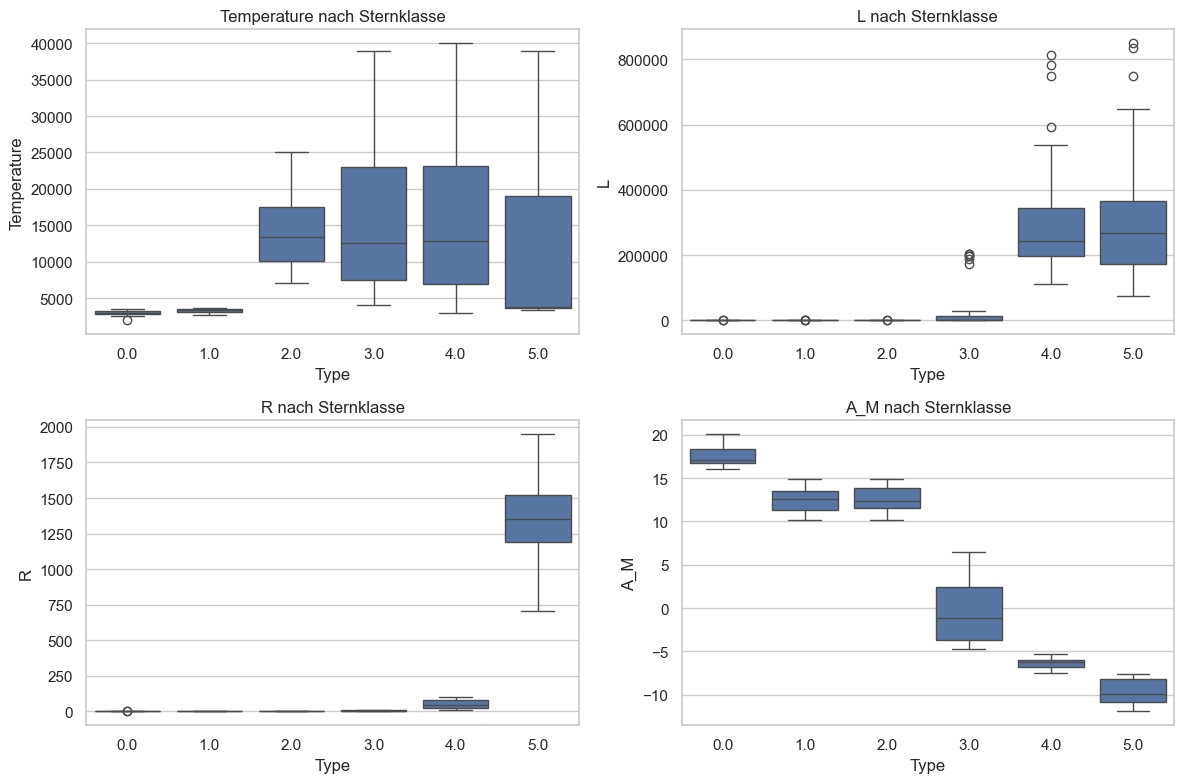

In [44]:
# Wir und Chat Gpt erstellen eine Grafik mit 2 Zeilen und 2 Spalten für unsere vier numerischen Merkmale.
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Wir machen aus den Achsen eine einfache Liste, damit wir leichter darüber iterieren können.
axes = axes.ravel()

# Wir erstellen für jedes numerische Merkmal einen Boxplot.
for ax, col in zip(axes, numeric_cols):
    # Der Boxplot zeigt, wie sich die Werte je nach Sternklasse unterscheiden.
    sns.boxplot(data=raw, x="Type", y=col, ax=ax)

    # Wir geben jedem Diagramm einen passenden Titel.
    ax.set_title(f"{col} nach Sternklasse")

# Wir sorgen dafür, dass sich die Diagramme nicht überlappen.
plt.tight_layout()

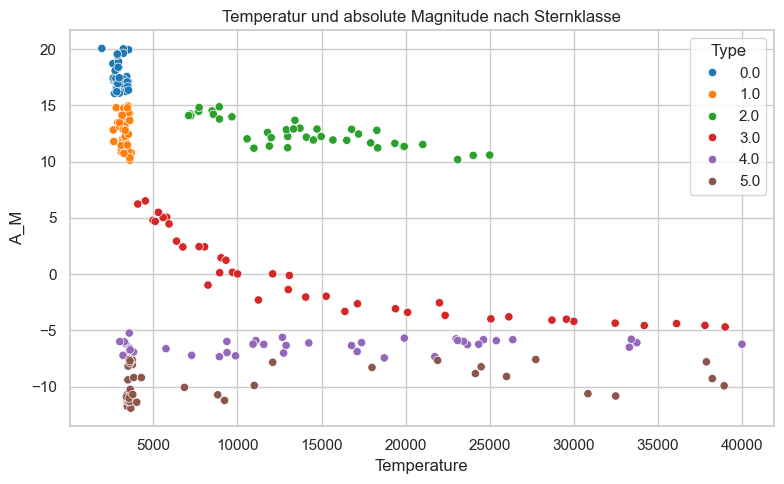

In [45]:
# Wir legen die Größe der Grafik fest.
plt.figure(figsize=(8, 5))

# Wir erstellen ein Streudiagramm (hat besser geklappt als bei den Aliens in der Vorlesung...das sah sehr wild aus bei mir) mit Temperatur und absoluter Magnitude.
# Die Farben zeigen dabei die verschiedenen Sternklassen.
sns.scatterplot(data=raw, x="Temperature", y="A_M", hue="Type", palette="tab10")

# Wir geben dem Diagramm einen Titel.
plt.title("Temperatur und absolute Magnitude nach Sternklasse")

# Wir sorgen dafür, dass alles sauber dargestellt wird.
plt.tight_layout()

## 5. Cleaning-Strategie

Die Originaldatei natürlich wird nicht manuell überschrieben. Stattdessen wird eine reproduzierbare Cleaning-Funktion definiert:

- Leere Strings werden als fehlende Werte behandelt.
- Numerische Spalten werden sicher in Zahlen konvertiert.
- `Color` wird vereinheitlicht, zb. Schreibfehler und verschiedene Schreibweisen werden zusammengeführt.
- `Spectral_Class` wird bereinigt und leere Werte werden später im Pipeline-Schritt imputiert.
- Fehlende numerische Werte werden mit dem Median imputiert.
- Kategoriale Werte werden mit dem häufigsten Wert imputiert und per One-Hot-Encoding codiert.

In [46]:
# Wir schreiben eine eigene Funktion, um den Datensatz zu bereinigen.
def clean_star_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    # Wir erstellen zuerst eine Kopie, damit wir die Originaldaten nicht verändern.
    cleaned = df.copy()

    # Wir gehen jede Spalte im Datensatz durch.
    for col in cleaned.columns:
        # Wenn die Spalte Text enthält, bereinigen wir die Textwerte.
        if cleaned[col].dtype == "object":
            # Wir wandeln die Werte in Text um und entfernen Leerzeichen am Anfang und Ende.
            cleaned[col] = cleaned[col].astype("string").str.strip()

            # Leere Texte ersetzen wir durch fehlende Werte.
            cleaned[col] = cleaned[col].replace({"": pd.NA})

    # Wir wandeln die numerischen Spalten wirklich in Zahlen um.
    for col in ["Temperature", "L", "R", "A_M", "Type"]:
        # Wenn ein Wert nicht in eine Zahl umgewandelt werden kann, wird daraus ein fehlender Wert.
        cleaned[col] = pd.to_numeric(cleaned[col], errors="coerce")

    # Wir erstellen eine Zuordnung, um unterschiedliche Schreibweisen der Farben zu vereinheitlichen.
    color_map = {
        "blu": "Blue",
        "blue": "Blue",
        "blue white": "Blue-white",
        "blue-white": "Blue-white",
        "blue-wh!te": "Blue-white",
        "white": "White",
        "whitish": "White",
        "white-yellow": "Yellow-white",
        "yellowish white": "Yellow-white",
        "yellow-white": "Yellow-white",
        "yellowish": "Yellowish",
        "pale yellow orange": "Pale yellow orange",
        "orange": "Orange",
        "orange-red": "Orange-red",
        "red": "Red",
    }

    # Wir machen die Farbnamen zuerst klein und ersetzen Unterstriche durch Leerzeichen.
    normalized_color = cleaned["Color"].str.lower().str.replace("_", " ", regex=False).str.replace(r"\s+", " ", regex=True)

    # Wir ersetzen die unterschiedlichen Farbschreibweisen durch einheitliche Namen.
    cleaned["Color"] = normalized_color.map(color_map).fillna(cleaned["Color"])

    # Wir schreiben die Spektralklassen einheitlich in Großbuchstaben.
    cleaned["Spectral_Class"] = cleaned["Spectral_Class"].str.upper()

    # Wir sorgen dafür, dass fehlende Werte bei den Textspalten korrekt als np.nan gespeichert werden.
    cleaned[["Color", "Spectral_Class"]] = cleaned[["Color", "Spectral_Class"]].astype(object).where(
        cleaned[["Color", "Spectral_Class"]].notna(), np.nan
    )

    # Wir wandeln die Zielvariable Type in ganze Zahlen um.
    cleaned["Type"] = cleaned["Type"].astype("Int64")

    # Wir geben den bereinigten Datensatz zurück.
    return cleaned

# Wir wenden unsere Bereinigungsfunktion auf die Rohdaten an.
data = clean_star_dataframe(raw)

# Wir schauen uns jetzt die ersten fünf Zeilen des bereinigten Datensatzes an (hoffentlich klappts).
data.head()

,Temperature,L,R,A_M,Color,Spectral_Class,Type
0,3068.0,0.002400,0.1700,16.12,Red,M,0
1,3042.0,0.000500,0.1542,16.60,Red,M,0
2,2600.0,0.000300,0.1020,18.70,Red,M,0
3,2800.0,0.000200,0.1600,16.65,Red,M,0
4,1939.0,0.000138,0.1030,20.06,Red,M,0


In [47]:
# Wir prüfen nach der Bereinigung noch einmal, wo fehlende Werte vorhanden sind.
data.isna().sum()


Temperature       39
L                 35
R                 38
A_M               35
Color             40
Spectral_Class    38
Type              35
dtype: int64

In [48]:
# Wir schauen uns die bereinigten Farbkategorien an.
# Dadurch sehen wir, ob die Vereinheitlichung funktioniert hat.
data["Color"].value_counts(dropna=False)

Color
Red                   109
Blue                   54
Blue-white             41
NaN                    40
White                  13
Yellow-white           11
Yellowish               3
Orange                  2
Pale yellow orange      1
Orange-red              1
Name: count, dtype: int64

## 6. Machine-Learning-Pipeline

Wir verwenden eine `ColumnTransformer`-Pipeline. Das verhindert Data Leakage, weil Imputation, Skalierung und One-Hot-Encoding nur auf den Trainingsdaten gelernt werden und anschliessend auf Testdaten angewendet werden.

In [49]:
# Wir trennen die Eingabedaten von der Zielvariable.
X = data.drop(columns="Type")

# Unsere Zielvariable ist Type, also die Sternklasse.
# Das "Int64" erlaubt NaN-Werte in einer Integer-Spalte 
# > da hatten wir davor nämlich (y = data["Type"].astype(int)) und es gab eine fehlermeldung, deshalbt haben wir Chat Got um hilfe gebeten 
y = data["Type"].astype("Int64")

# Wir legen fest, welche Merkmale numerisch sind.
numeric_features = ["Temperature", "L", "R", "A_M"]

# Wir legen fest, welche Merkmale kategorial sind.
categorical_features = ["Color", "Spectral_Class"]

# Wir erstellen eine Pipeline für die numerischen Spalten.
numeric_preprocess = Pipeline(steps=[
    # Fehlende numerische Werte ersetzen wir durch den Median.
    ("imputer", SimpleImputer(strategy="median")),

    # Danach skalieren wir die numerischen Werte.
    ("scaler", StandardScaler()),
])

# Wir erstellen eine Pipeline für die kategorialen Spalten.
categorical_preprocess = Pipeline(steps=[
    # Fehlende Textwerte ersetzen wir durch den häufigsten Wert.
    ("imputer", SimpleImputer(strategy="most_frequent")),

    # Danach wandeln wir Kategorien in Zahlen-Spalten um.
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

# Wir verbinden die numerische und kategoriale Vorverarbeitung.
preprocessor = ColumnTransformer(transformers=[
    # Diese Schritte werden auf die numerischen Merkmale angewendet.
    ("num", numeric_preprocess, numeric_features),

    # Diese Schritte werden auf die kategorialen Merkmale angewendet.
    ("cat", categorical_preprocess, categorical_features),
])

In [50]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "Support Vector Machine": SVC(kernel="rbf", C=10, gamma="scale", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results = []
for name, model in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", model)])
    scores = cross_validate(pipe, X, y, cv=cv, scoring=["accuracy", "f1_macro"], return_train_score=False)
    results.append({
        "model": name,
        "accuracy_mean": scores["test_accuracy"].mean(),
        "accuracy_std": scores["test_accuracy"].std(),
        "f1_macro_mean": scores["test_f1_macro"].mean(),
        "f1_macro_std": scores["test_f1_macro"].std(),
    })

results_df = pd.DataFrame(results).sort_values("f1_macro_mean", ascending=False)
results_df

ValueError: Input y contains NaN.

## 7. Finales Modell evaluieren

Nach dem Modellvergleich trainieren wir das beste Modell auf einem Trainingssplit und bewerten es auf einem separaten Testsplit. Wegen der kleinen Datenmenge ist Cross Validation wichtiger als ein einzelner Split; der Split hilft aber, eine konkrete Confusion Matrix und einen Classification Report zu zeigen.

In [ ]:
best_model_name = results_df.iloc[0]["model"]
best_model = models[best_model_name]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

final_pipeline = Pipeline(steps=[("preprocess", preprocessor), ("model", best_model)])
final_pipeline.fit(X_train, y_train)
y_pred = final_pipeline.predict(X_test)

print(f"Bestes Modell laut Cross Validation: {best_model_name}")
print(f"Accuracy Testset: {accuracy_score(y_test, y_pred):.3f}")
print(f"Macro F1 Testset: {f1_score(y_test, y_pred, average='macro'):.3f}")
print(classification_report(y_test, y_pred))

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=sorted(y.unique()), yticklabels=sorted(y.unique()))
plt.xlabel("Vorhergesagte Klasse")
plt.ylabel("Tatsaechliche Klasse")
plt.title(f"Confusion Matrix: {best_model_name}")
plt.tight_layout()

## 8. Interpretation und Fazit

Die Sternklassifikation eignet sich gut als ueberwachtes Lernproblem, weil die Zielvariable `Type` vollstaendig vorhanden und balanciert ist. Die wichtigsten Vorverarbeitungsschritte sind das robuste Laden der Datei, die Vereinheitlichung von Farbkategorien, die Behandlung fehlender Werte und die Skalierung numerischer Features.

Fuer die Bewertung werden **Accuracy** und **Macro F1** verwendet. Accuracy ist wegen der balancierten Klassen gut interpretierbar. Macro F1 ist trotzdem sinnvoll, weil jede Klasse gleich stark gewichtet wird und damit schwache Leistung in einzelnen Klassen sichtbar bleibt.

Aufgrund der kleinen Datenmenge von 240 Beobachtungen sollte die Modellqualitaet nicht nur ueber einen einzelnen Train-Test-Split beurteilt werden. Die 5-fache stratified Cross Validation liefert eine stabilere Schaetzung.

## 9. Grenzen und moegliche Verbesserungen

- Das Dataset ist klein, wodurch Ergebnisse je nach Split schwanken koennen.
- Einige fehlende Werte koennten astrophysikalisch fundierter imputiert werden, z. B. anhand aehnlicher Sternklassen oder physikalischer Beziehungen.
- `Color` enthaelt Schreibfehler und uneinheitliche Labels. Die hier genutzte Mapping-Tabelle ist transparent, aber fachlich diskutierbar.
- Eine Hyperparameter-Optimierung mit `GridSearchCV` oder `RandomizedSearchCV` koennte die Modelle weiter verbessern.
- Feature Engineering mit logarithmierten Werten fuer `L` und `R` koennte sinnvoll sein, weil diese Variablen sehr grosse Wertebereiche besitzen.

## 10. Dokumentation der LLM-Nutzung

Fuer dieses Projekt wurde ein Large Language Model als Unterstuetzung verwendet. Genutzt wurde es fuer:

- Strukturierung des Notebooks und des Abschlussberichts
- Vorschlaege fuer eine geeignete Machine-Learning-Strategie
- Formulierung einer reproduzierbaren Cleaning- und Preprocessing-Pipeline
- Hinweise zur Dokumentation typischer Datenprobleme

Die Verantwortung fuer Code, Interpretation und finale Abgabe liegt vollstaendig bei der Gruppe. Alle Gruppenmitglieder muessen die Schritte im Notebook nachvollziehen und erklaeren koennen.